<a href="https://colab.research.google.com/github/jyeon6273/DeepNeuralNetworks/blob/main/Assignment_1_CIFAR10_Autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CIFAR-10 Autoencoder - Assignment 1

## Objectives
- Build a convolutional autoencoder.
- Understand encoder, latent code, decoder, and reconstruction loss.
- Compare latent dimensions.
- Visualize original vs reconstructed images.
- Train a denoising autoencoder.
- Visualize latent features with PCA.


In [1]:
import random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms
from sklearn.decomposition import PCA

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCHS = 5
BATCH_SIZE = 128
FAST_MODE = False

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()
print("Device:", DEVICE)

Device: cuda


## 1. Load CIFAR-10

CIFAR-10 has 32×32 RGB images from 10 classes.  
For a normal autoencoder, the target is the input itself:

`input x → encoder → latent z → decoder → reconstruction x'`

The model minimizes reconstruction error between `x` and `x'`.


In [2]:
transform = transforms.ToTensor()

full_train = datasets.CIFAR10("./data", train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10("./data", train=False, download=True, transform=transform)

train_dataset, val_dataset = random_split(
    full_train, [45000, 5000],
    generator=torch.Generator().manual_seed(SEED)
)

if FAST_MODE:
    train_dataset = Subset(train_dataset, range(12000))
    val_dataset = Subset(val_dataset, range(2000))
    test_dataset = Subset(test_dataset, range(2000))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

classes = full_train.classes
print(classes)


100%|██████████| 170M/170M [00:30<00:00, 5.63MB/s]


['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


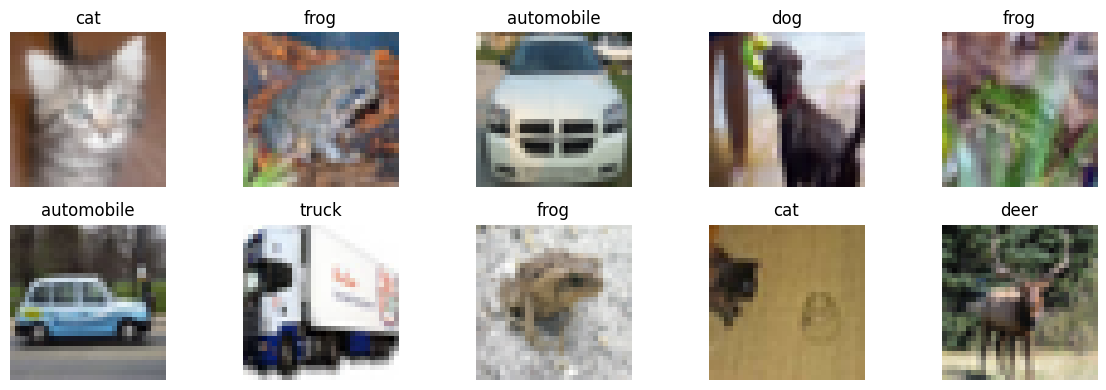

In [3]:
images, labels = next(iter(train_loader))
plt.figure(figsize=(12,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(images[i].permute(1,2,0))
    plt.title(classes[labels[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

## 2. Convolutional Autoencoder

Architecture:

`3×32×32 → 32×16×16 → 64×8×8 → 128×4×4 → latent z → decoder → 3×32×32`

The latent vector is the **bottleneck**.


In [4]:
class ConvAutoencoder(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        self.latent_dim = latent_dim

        self.encoder_conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, 2, 1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, 2, 1), nn.ReLU(),
            nn.Conv2d(64, 128, 3, 2, 1), nn.ReLU()
        )

        self.fc_encode = nn.Linear(128*4*4, latent_dim)
        self.fc_decode = nn.Linear(latent_dim, 128*4*4)

        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1), nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder_conv(x)
        h = h.view(x.size(0), -1)
        return self.fc_encode(h)

    def decode(self, z):
        h = self.fc_decode(z).view(-1, 128, 4, 4)
        return self.decoder_conv(h)

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z), z


## 3. Reconstruction Loss

We use Mean Squared Error (MSE):

This is not classification. The model learns to reconstruct the image.


In [5]:
criterion = nn.MSELoss()

def evaluate(model, loader):
    model.eval()
    total_loss, total_n = 0.0, 0
    with torch.no_grad():
        for x, _ in loader:
            x = x.to(DEVICE)
            recon, _ = model(x)
            loss = criterion(recon, x)
            total_loss += loss.item() * x.size(0)
            total_n += x.size(0)
    return total_loss / total_n

def train_autoencoder(model, epochs=EPOCHS, lr=1e-3):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "val_loss": []}
    start = time.perf_counter()

    for epoch in range(1, epochs+1):
        model.train()
        total_loss, total_n = 0.0, 0

        for x, _ in train_loader:
            x = x.to(DEVICE)
            optimizer.zero_grad()
            recon, _ = model(x)
            loss = criterion(recon, x)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * x.size(0)
            total_n += x.size(0)

        train_loss = total_loss / total_n
        val_loss = evaluate(model, val_loader)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        print(f"Epoch {epoch:02d}/{epochs} | train {train_loss:.5f} | val {val_loss:.5f}")

    return history, time.perf_counter() - start


# Task 1 — Basic Autoencoder

Start with `latent_dim = 64`.


In [6]:
set_seed()
model64 = ConvAutoencoder(latent_dim=64)
history64, train_time = train_autoencoder(model64, epochs=EPOCHS)
print("Test loss:", evaluate(model64, test_loader))
print("Train time:", round(train_time,1), "s")


Epoch 01/5 | train 0.02519 | val 0.01401
Epoch 02/5 | train 0.01173 | val 0.01044
Epoch 03/5 | train 0.00938 | val 0.00881
Epoch 04/5 | train 0.00842 | val 0.00822
Epoch 05/5 | train 0.00807 | val 0.00819
Test loss: 0.008148289415240288
Train time: 55.0 s


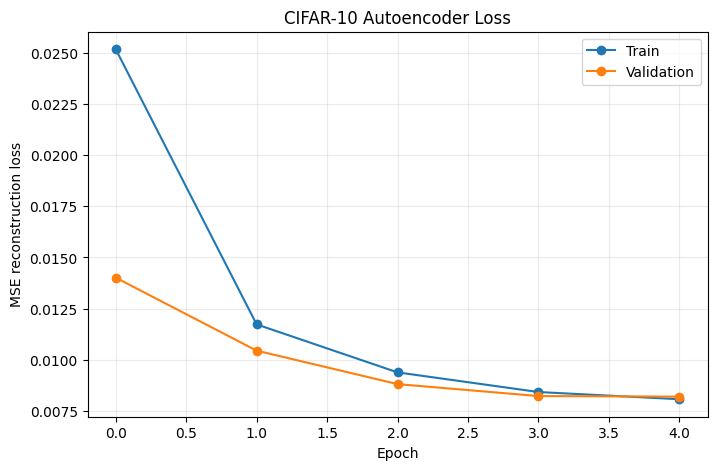

In [7]:
plt.figure(figsize=(8,5))
plt.plot(history64["train_loss"], marker="o", label="Train")
plt.plot(history64["val_loss"], marker="o", label="Validation")
plt.xlabel("Epoch")
plt.ylabel("MSE reconstruction loss")
plt.title("CIFAR-10 Autoencoder Loss")
plt.grid(alpha=.25)
plt.legend()
plt.show()


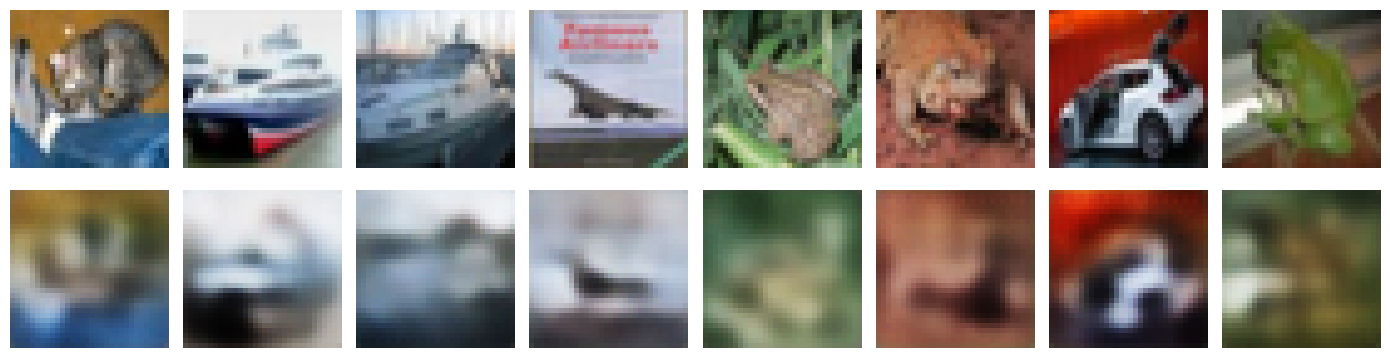

In [8]:
def show_reconstructions(model, loader, n=8):
    model.eval()
    x, _ = next(iter(loader))
    x = x[:n].to(DEVICE)
    with torch.no_grad():
        recon, _ = model(x)

    plt.figure(figsize=(14,4))
    for i in range(n):
        plt.subplot(2,n,i+1)
        plt.imshow(x[i].cpu().permute(1,2,0))
        plt.axis("off")
        if i == 0: plt.ylabel("Original")

        plt.subplot(2,n,n+i+1)
        plt.imshow(recon[i].cpu().permute(1,2,0).clamp(0,1))
        plt.axis("off")
        if i == 0: plt.ylabel("Reconstructed")
    plt.tight_layout()
    plt.show()

show_reconstructions(model64, test_loader)


# Task 2 — Latent Dimension

Compare `32, 64, 128, 256`.

Expected idea:
- smaller latent space → stronger compression, more information loss
- larger latent space → easier reconstruction, less compression


In [9]:
latent_dims = [32, 64, 128, 256]
latent_models = {}
latent_histories = {}
results = []

for d in latent_dims:
    print("\nLATENT DIM =", d)
    set_seed()
    model = ConvAutoencoder(d)
    history, t = train_autoencoder(model, epochs=EPOCHS)
    test_loss = evaluate(model, test_loader)

    latent_models[d] = model
    latent_histories[d] = history
    results.append({
        "Latent Dimension": d,
        "Test Reconstruction Loss": test_loss,
        "Train Time (s)": t
    })

pd.DataFrame(results)



LATENT DIM = 32
Epoch 01/5 | train 0.02545 | val 0.01496
Epoch 02/5 | train 0.01333 | val 0.01253
Epoch 03/5 | train 0.01236 | val 0.01228
Epoch 04/5 | train 0.01212 | val 0.01205
Epoch 05/5 | train 0.01192 | val 0.01193

LATENT DIM = 64
Epoch 01/5 | train 0.02512 | val 0.01384
Epoch 02/5 | train 0.01170 | val 0.01026
Epoch 03/5 | train 0.00935 | val 0.00912
Epoch 04/5 | train 0.00844 | val 0.00825
Epoch 05/5 | train 0.00811 | val 0.00822

LATENT DIM = 128
Epoch 01/5 | train 0.02313 | val 0.01249
Epoch 02/5 | train 0.01081 | val 0.00965
Epoch 03/5 | train 0.00851 | val 0.00767
Epoch 04/5 | train 0.00706 | val 0.00657
Epoch 05/5 | train 0.00621 | val 0.00597

LATENT DIM = 256
Epoch 01/5 | train 0.02369 | val 0.01246
Epoch 02/5 | train 0.01024 | val 0.00873
Epoch 03/5 | train 0.00774 | val 0.00688
Epoch 04/5 | train 0.00639 | val 0.00601
Epoch 05/5 | train 0.00554 | val 0.00522


,Latent Dimension,Test Reconstruction Loss,Train Time (s)
0,32,0.011930,49.464690
1,64,0.008171,52.327396
2,128,0.005928,50.576070
3,256,0.005174,50.229390


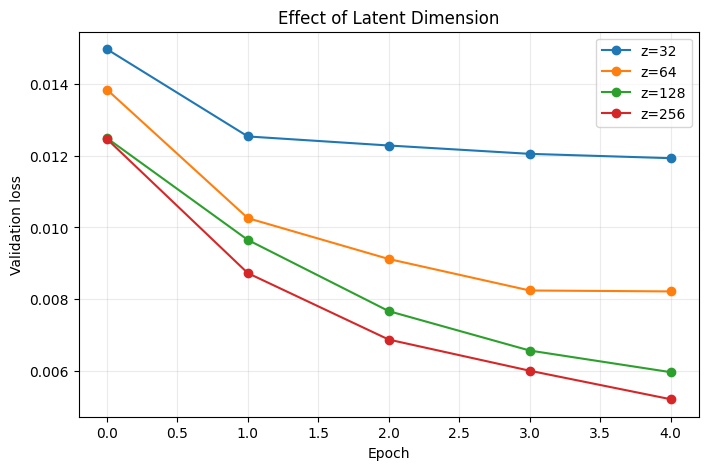

In [10]:
plt.figure(figsize=(8,5))
for d in latent_dims:
    plt.plot(latent_histories[d]["val_loss"], marker="o", label=f"z={d}")
plt.xlabel("Epoch")
plt.ylabel("Validation loss")
plt.title("Effect of Latent Dimension")
plt.grid(alpha=.25)
plt.legend()
plt.show()


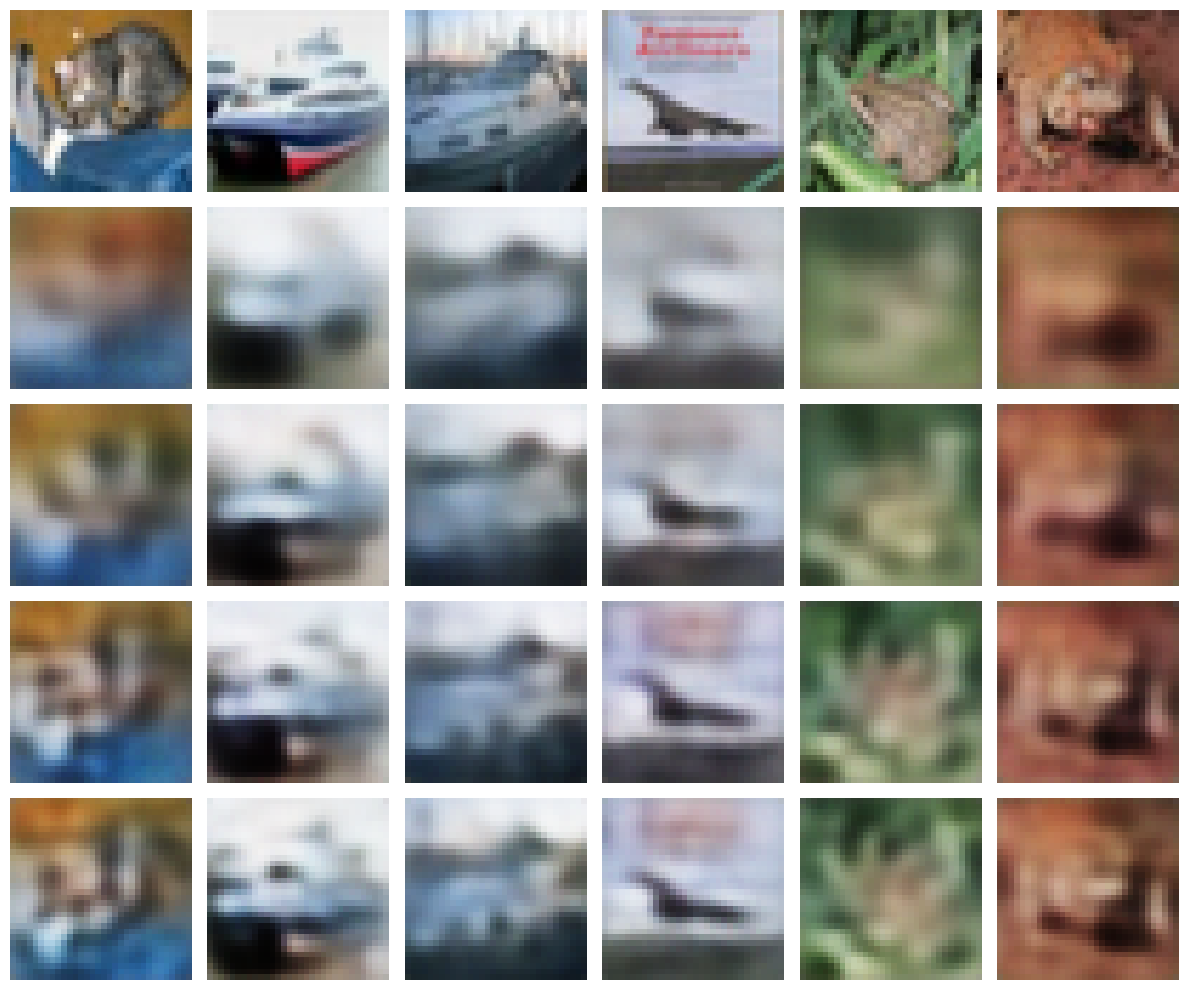

In [11]:
x, _ = next(iter(test_loader))
x = x[:6].to(DEVICE)

plt.figure(figsize=(12,10))
for i in range(6):
    plt.subplot(len(latent_dims)+1, 6, i+1)
    plt.imshow(x[i].cpu().permute(1,2,0))
    plt.axis("off")
    if i == 0: plt.ylabel("Original")

for row, d in enumerate(latent_dims, start=1):
    latent_models[d].eval()
    with torch.no_grad():
        recon, _ = latent_models[d](x)
    for i in range(6):
        plt.subplot(len(latent_dims)+1, 6, row*6+i+1)
        plt.imshow(recon[i].cpu().permute(1,2,0).clamp(0,1))
        plt.axis("off")
        if i == 0: plt.ylabel(f"z={d}")

plt.tight_layout()
plt.show()


# Task 3 — Denoising Autoencoder

Input = noisy image  
Target = clean image


In [12]:
def add_noise(x, std=0.20):
    return torch.clamp(x + std*torch.randn_like(x), 0, 1)

def train_denoising(model, noise_std=0.20, epochs=EPOCHS):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(1, epochs+1):
        model.train()
        total_loss, total_n = 0.0, 0

        for clean, _ in train_loader:
            clean = clean.to(DEVICE)
            noisy = add_noise(clean, noise_std)

            optimizer.zero_grad()
            recon, _ = model(noisy)
            loss = criterion(recon, clean)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()*clean.size(0)
            total_n += clean.size(0)

        print(f"Epoch {epoch:02d}/{epochs} | loss {total_loss/total_n:.5f}")

    return model

set_seed()
denoise_model = ConvAutoencoder(64)
denoise_model = train_denoising(denoise_model, noise_std=0.20)


Epoch 01/5 | loss 0.02697
Epoch 02/5 | loss 0.01291
Epoch 03/5 | loss 0.01078
Epoch 04/5 | loss 0.00968
Epoch 05/5 | loss 0.00918


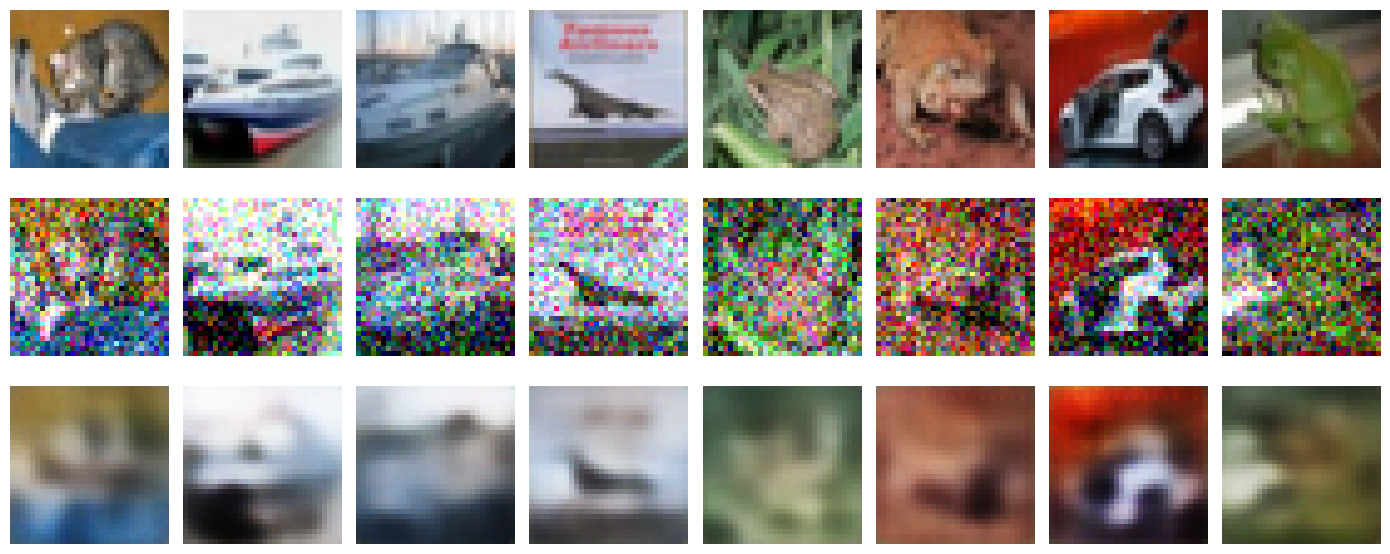

In [13]:
clean, _ = next(iter(test_loader))
clean = clean[:8].to(DEVICE)
noisy = add_noise(clean, 0.20)

denoise_model.eval()
with torch.no_grad():
    recon, _ = denoise_model(noisy)

plt.figure(figsize=(14,6))
for i in range(8):
    plt.subplot(3,8,i+1)
    plt.imshow(clean[i].cpu().permute(1,2,0)); plt.axis("off")
    if i == 0: plt.ylabel("Clean")

    plt.subplot(3,8,8+i+1)
    plt.imshow(noisy[i].cpu().permute(1,2,0)); plt.axis("off")
    if i == 0: plt.ylabel("Noisy")

    plt.subplot(3,8,16+i+1)
    plt.imshow(recon[i].cpu().permute(1,2,0).clamp(0,1)); plt.axis("off")
    if i == 0: plt.ylabel("Denoised")

plt.tight_layout()
plt.show()


# Experiment 4 — Latent Space Visualization

The autoencoder uses a 64-D latent space.  
For visualization only, we project it to 2D with PCA.

Do not expect perfect class separation because the autoencoder was trained for reconstruction, not classification.


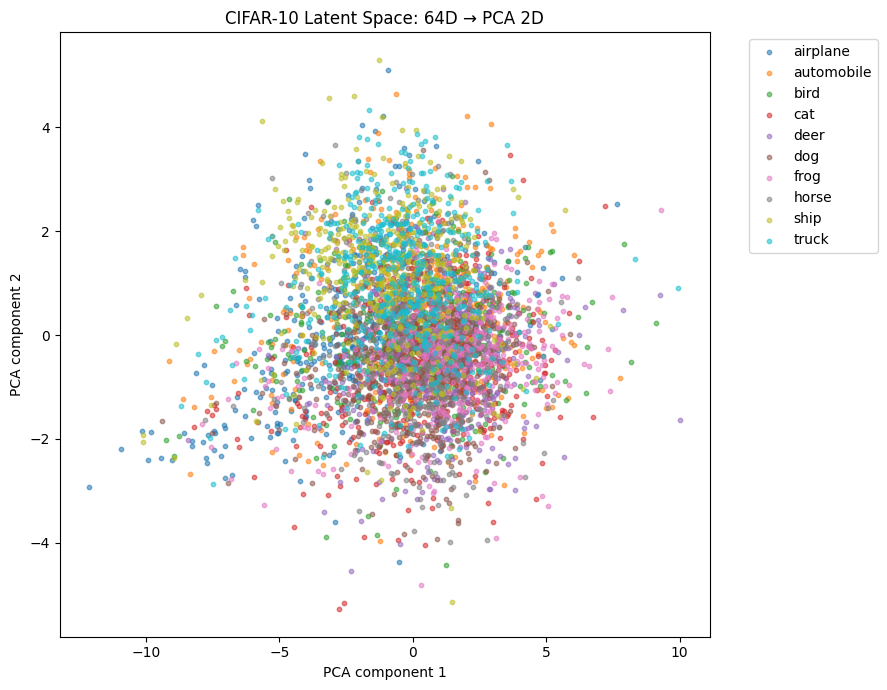

In [14]:
def collect_latents(model, loader, max_samples=5000):
    model.eval()
    Z, Y = [], []
    count = 0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            z = model.encode(x).cpu()
            Z.append(z)
            Y.append(y)
            count += x.size(0)
            if count >= max_samples:
                break

    return torch.cat(Z)[:max_samples].numpy(), torch.cat(Y)[:max_samples].numpy()

z, y = collect_latents(model64, test_loader)
z2 = PCA(n_components=2).fit_transform(z)

plt.figure(figsize=(9,7))
for c, name in enumerate(classes):
    mask = y == c
    plt.scatter(z2[mask,0], z2[mask,1], s=10, alpha=.55, label=name)

plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.title("CIFAR-10 Latent Space: 64D → PCA 2D")
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")
plt.tight_layout()
plt.show()


In [16]:
import inspect
print(inspect.signature(train_autoencoder))

(model, epochs=5, lr=0.001)


In [17]:
# Final Improved Model
improved_model = ConvAutoencoder(latent_dim=256).to(DEVICE)

improved_history, improved_time = train_autoencoder(
    improved_model,
    epochs=10,
    lr=0.001
)

improved_test_loss = evaluate(improved_model, test_loader)

print("Improved Test Loss:", improved_test_loss)
print("Training Time:", improved_time)

Epoch 01/10 | train 0.02373 | val 0.01251
Epoch 02/10 | train 0.01050 | val 0.00875
Epoch 03/10 | train 0.00781 | val 0.00704
Epoch 04/10 | train 0.00644 | val 0.00603
Epoch 05/10 | train 0.00560 | val 0.00526
Epoch 06/10 | train 0.00496 | val 0.00476
Epoch 07/10 | train 0.00454 | val 0.00442
Epoch 08/10 | train 0.00423 | val 0.00410
Epoch 09/10 | train 0.00397 | val 0.00386
Epoch 10/10 | train 0.00375 | val 0.00368
Improved Test Loss: 0.0036465057663619517
Training Time: 106.25293803499994


In [20]:
import inspect
print(inspect.getsource(ConvAutoencoder.forward))

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z), z



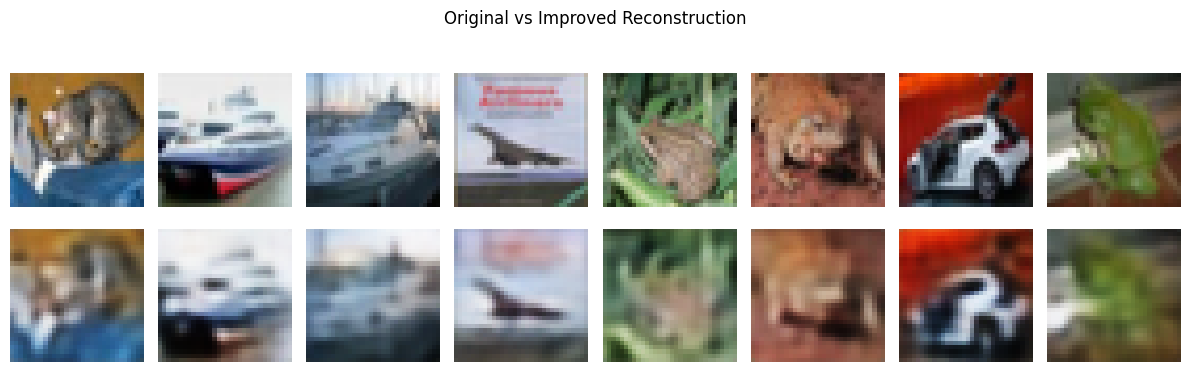

In [21]:
# Compare original and improved reconstructions

improved_model.eval()

x, _ = next(iter(test_loader))
x = x.to(DEVICE)

with torch.no_grad():
    recon, z = improved_model(x)

x = x.cpu()
recon = recon.cpu()

plt.figure(figsize=(12, 4))

for i in range(8):
    # Original
    plt.subplot(2, 8, i + 1)
    plt.imshow(x[i].permute(1, 2, 0))
    plt.axis("off")

    # Reconstruction
    plt.subplot(2, 8, 8 + i + 1)
    plt.imshow(recon[i].permute(1, 2, 0))
    plt.axis("off")

plt.suptitle("Original vs Improved Reconstruction")
plt.tight_layout()
plt.show()

In [ ]:
# Trial 2

In [22]:
class ImprovedConvAutoencoder(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, 2, 1),      # 32x32 -> 16x16
            nn.ReLU(),

            nn.Conv2d(32, 64, 3, 2, 1),     # 16x16 -> 8x8
            nn.ReLU(),

            nn.Conv2d(64, 128, 3, 2, 1),     # 8x8 -> 4x4
            nn.ReLU(),

            nn.Conv2d(128, 256, 3, 1, 1),   # 4x4 -> 4x4
            nn.ReLU()
        )

        self.fc_enc = nn.Linear(256 * 4 * 4, latent_dim)
        self.fc_dec = nn.Linear(latent_dim, 256 * 4 * 4)

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 3, 1, 1),
            nn.ReLU(),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 3, 4, 2, 1),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        h = h.flatten(1)
        return self.fc_enc(h)

    def decode(self, z):
        h = self.fc_dec(z)
        h = h.view(-1, 256, 4, 4)
        return self.decoder(h)

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z), z

In [23]:
architecture_model = ImprovedConvAutoencoder(latent_dim=256).to(DEVICE)

In [24]:
architecture_history, architecture_time = train_autoencoder(
    architecture_model,
    epochs=10,
    lr=0.001
)

Epoch 01/10 | train 0.02795 | val 0.01636
Epoch 02/10 | train 0.01372 | val 0.01182
Epoch 03/10 | train 0.01086 | val 0.00993
Epoch 04/10 | train 0.00929 | val 0.00867
Epoch 05/10 | train 0.00821 | val 0.00776
Epoch 06/10 | train 0.00745 | val 0.00714
Epoch 07/10 | train 0.00688 | val 0.00690
Epoch 08/10 | train 0.00636 | val 0.00636
Epoch 09/10 | train 0.00597 | val 0.00582
Epoch 10/10 | train 0.00561 | val 0.00554


In [25]:
# Trial 3
trial3_model = ImprovedConvAutoencoder(latent_dim=256).to(DEVICE)

trial3_history, trial3_time = train_autoencoder(
    trial3_model,
    epochs=20,
    lr=0.001
)

trial3_test_loss = evaluate(trial3_model, test_loader)

print("Trial 3 Test Loss:", trial3_test_loss)
print("Trial 3 Training Time:", trial3_time)

Epoch 01/20 | train 0.02884 | val 0.01597
Epoch 02/20 | train 0.01329 | val 0.01147
Epoch 03/20 | train 0.01038 | val 0.00951
Epoch 04/20 | train 0.00885 | val 0.00836
Epoch 05/20 | train 0.00782 | val 0.00747
Epoch 06/20 | train 0.00713 | val 0.00697
Epoch 07/20 | train 0.00655 | val 0.00635
Epoch 08/20 | train 0.00608 | val 0.00639
Epoch 09/20 | train 0.00571 | val 0.00560
Epoch 10/20 | train 0.00543 | val 0.00527
Epoch 11/20 | train 0.00514 | val 0.00509
Epoch 12/20 | train 0.00490 | val 0.00484
Epoch 13/20 | train 0.00470 | val 0.00460
Epoch 14/20 | train 0.00450 | val 0.00447
Epoch 15/20 | train 0.00433 | val 0.00444
Epoch 16/20 | train 0.00421 | val 0.00432
Epoch 17/20 | train 0.00410 | val 0.00440
Epoch 18/20 | train 0.00400 | val 0.00410
Epoch 19/20 | train 0.00389 | val 0.00403
Epoch 20/20 | train 0.00376 | val 0.00383
Trial 3 Test Loss: 0.003793294655904174
Trial 3 Training Time: 222.3241096920001


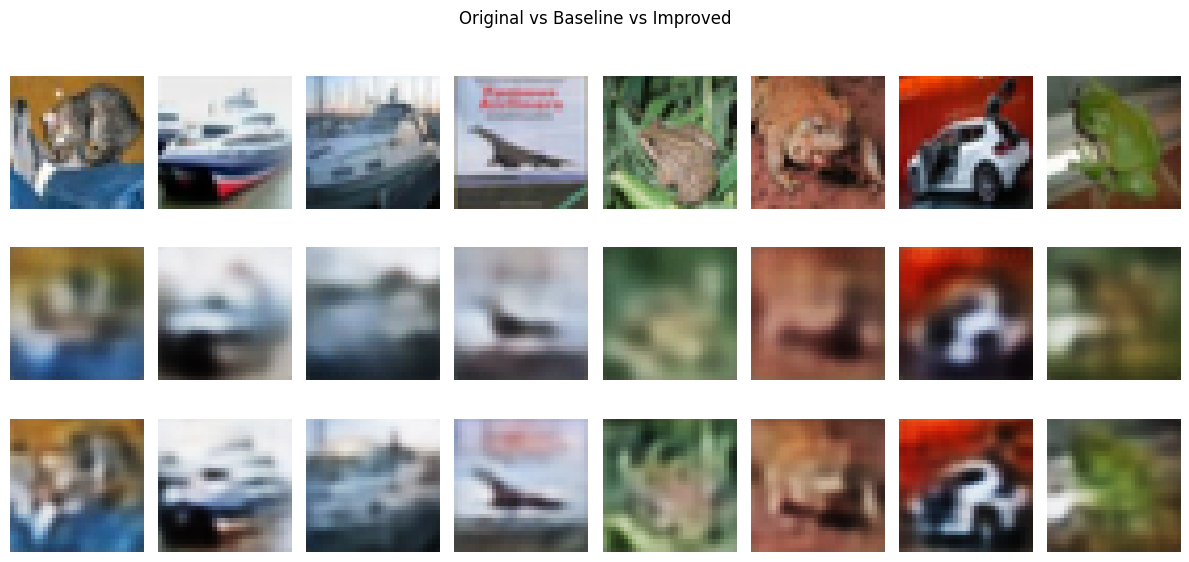

In [26]:
improved_model.eval()
model64.eval()

x, _ = next(iter(test_loader))
x = x.to(DEVICE)

with torch.no_grad():
    baseline_recon, _ = model64(x)
    improved_recon, _ = improved_model(x)

x = x.cpu()
baseline_recon = baseline_recon.cpu()
improved_recon = improved_recon.cpu()

plt.figure(figsize=(12, 6))

for i in range(8):
    # Original
    plt.subplot(3, 8, i + 1)
    plt.imshow(x[i].permute(1, 2, 0))
    plt.axis("off")

    # Baseline
    plt.subplot(3, 8, 8 + i + 1)
    plt.imshow(baseline_recon[i].permute(1, 2, 0))
    plt.axis("off")

    # Improved
    plt.subplot(3, 8, 16 + i + 1)
    plt.imshow(improved_recon[i].permute(1, 2, 0))
    plt.axis("off")

plt.suptitle("Original vs Baseline vs Improved")
plt.tight_layout()
plt.show()

In [27]:
# Trial 4
trial4_model = ConvAutoencoder(latent_dim=256).to(DEVICE)

trial4_history, trial4_time = train_autoencoder(
    trial4_model,
    epochs=20,
    lr=0.001
)

trial4_test_loss = evaluate(trial4_model, test_loader)

print("Trial 4 Test Loss:", trial4_test_loss)
print("Trial 4 Training Time:", trial4_time)

Epoch 01/20 | train 0.02281 | val 0.01235
Epoch 02/20 | train 0.01027 | val 0.00866
Epoch 03/20 | train 0.00765 | val 0.00693
Epoch 04/20 | train 0.00622 | val 0.00582
Epoch 05/20 | train 0.00537 | val 0.00520
Epoch 06/20 | train 0.00480 | val 0.00466
Epoch 07/20 | train 0.00444 | val 0.00431
Epoch 08/20 | train 0.00415 | val 0.00424
Epoch 09/20 | train 0.00388 | val 0.00378
Epoch 10/20 | train 0.00365 | val 0.00372
Epoch 11/20 | train 0.00346 | val 0.00340
Epoch 12/20 | train 0.00331 | val 0.00331
Epoch 13/20 | train 0.00318 | val 0.00316
Epoch 14/20 | train 0.00306 | val 0.00307
Epoch 15/20 | train 0.00298 | val 0.00296
Epoch 16/20 | train 0.00290 | val 0.00292
Epoch 17/20 | train 0.00283 | val 0.00285
Epoch 18/20 | train 0.00275 | val 0.00280
Epoch 19/20 | train 0.00270 | val 0.00276
Epoch 20/20 | train 0.00265 | val 0.00269
Trial 4 Test Loss: 0.002648779371380806
Trial 4 Training Time: 207.39546364700027


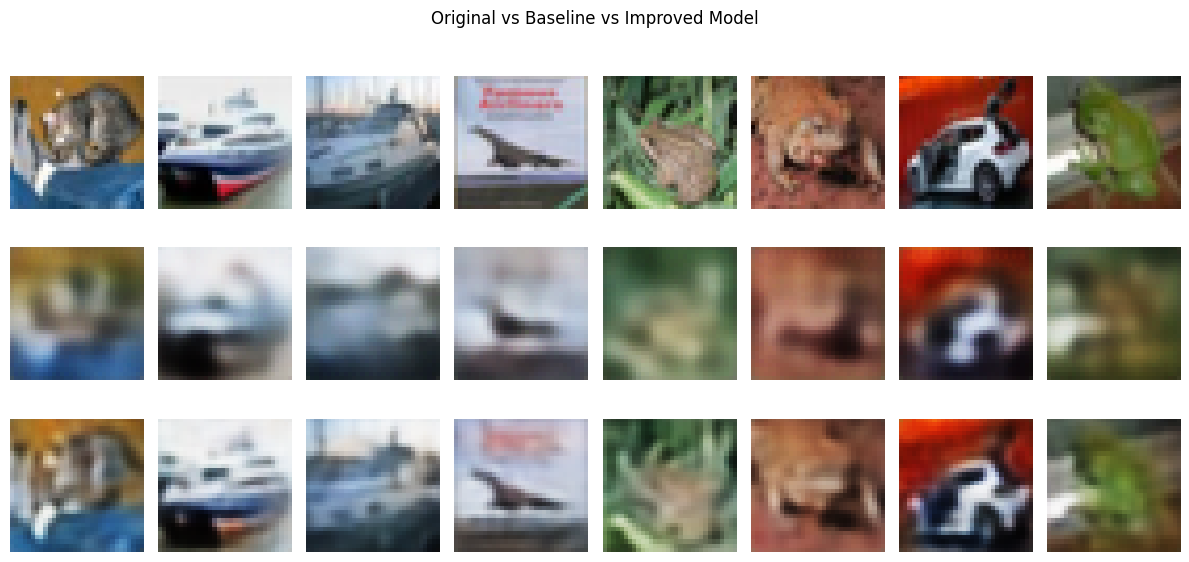

In [28]:
# Final visual comparison
model64.eval()
trial4_model.eval()

x, _ = next(iter(test_loader))
x = x.to(DEVICE)

with torch.no_grad():
    baseline_recon, _ = model64(x)
    trial4_recon, _ = trial4_model(x)

x = x.cpu()
baseline_recon = baseline_recon.cpu()
trial4_recon = trial4_recon.cpu()

plt.figure(figsize=(12, 6))

for i in range(8):
    # Original
    plt.subplot(3, 8, i + 1)
    plt.imshow(x[i].permute(1, 2, 0))
    plt.axis("off")

    # Baseline
    plt.subplot(3, 8, 8 + i + 1)
    plt.imshow(baseline_recon[i].permute(1, 2, 0))
    plt.axis("off")

    # Trial 4
    plt.subplot(3, 8, 16 + i + 1)
    plt.imshow(trial4_recon[i].permute(1, 2, 0))
    plt.axis("off")

plt.suptitle("Original vs Baseline vs Improved Model")
plt.tight_layout()
plt.show()